<a href="https://colab.research.google.com/github/GyeongHub/ESAA-OB/blob/main/week6_0407_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*0407(월) 6주차 과제*\
*파이썬 머신러닝 완벽 가이드 8장 텍스트 분석 - 10, 11 p.566-583*

# 10 텍스트 분석 실습 — 캐글 Mercari Price Suggestion Challenge

- Mercari Price Suggestion Challenge
    - 캐글에서 진행된 Challenge
    - 일본의 대형 온라인 쇼핑몰인 Mercari사의 제품에 대해 가격 예측
    - 제공되는 데이터 세트: 제품에 대한 여러 속성 및 제품 설명 등의 텍스트 데이터

- 제공 데이터 속성

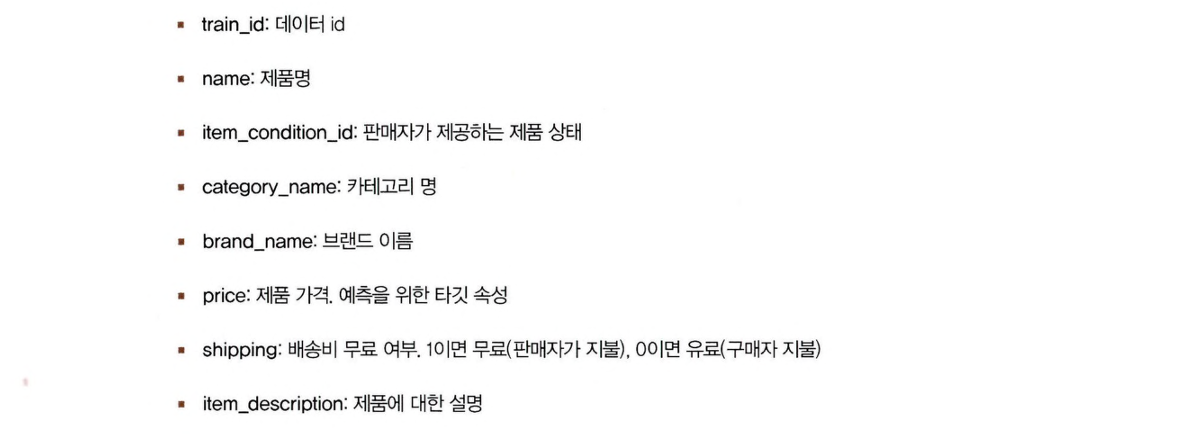

price: 예측해야 할 타깃 값

기존 회귀 예제와 다른 점: item_description과 같은 텍스트 형태의 비정형 데이터와 다른 정형 속성을 같이 적용해 회귀를 수행.

## 데이터 전처리

In [1]:
# 데이터 로드
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

mercari_df = pd.read_csv('/content/drive/MyDrive/ESAA/OB/data/mercari_train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


1482535개의 레코드를 가지고 있는 데이터 세트

In [3]:
# 피처의 타입과 Null 여부 확인

print(mercari_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB
None


brand_name 칼럼: 매우 많은 Null 값을 가지고 있음. (전체 1482535건 중에 849853건만 Not null) \
category_name 칼럼: 약 6300건의 null 값을 가지고 있음. \
item_desciption 칼럼: 4건의 null값을 가지고 있음.

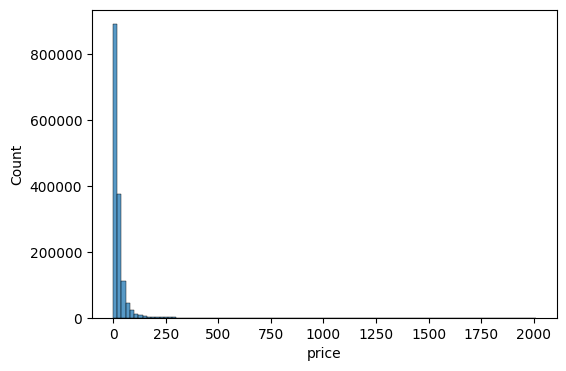

In [4]:
# Target 값인 price 칼럼의 데이터 분포도 확인

import matplotlib.pyplot as plt
import seaborn as sns

y_train_df = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df, bins=100)
plt.show()

price 값이 비교적 적은 가격을 가진 데이터 값에 왜곡돼 분포돼 있음.

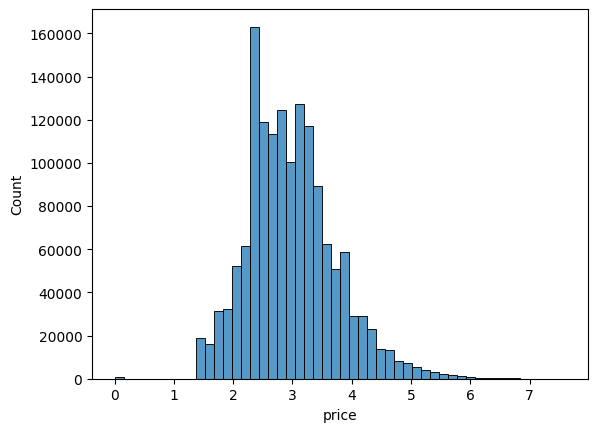

In [5]:
# Price 칼럼을 로그 값으로 변환한 뒤 분포도를 다시 확인

import numpy as np

y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

로그 값으로 변환 -> price 값이 비교적 정규 분포에 가까운 데이터가 됨.

In [6]:
# price 칼럼을 원래 값에서 로그로 변환된 값으로 변경

mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

,price
0,2.397895
1,3.970292
2,2.397895


In [7]:
# shipping과 item_condition_id 값의 유형 확인

print('Shipping 값 유형:\n', mercari_df['shipping'].value_counts())
print('item_condition_id 값 유형:\n', mercari_df['item_condition_id'].value_counts())

Shipping 값 유형:
 shipping
0    819435
1    663100
Name: count, dtype: int64
item_condition_id 값 유형:
 item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64


Shipping 칼럼: 배송비 유무이며, 값이 비교적 균일함. \
Item_condition_id 칼럼: 판매자가 제공하는 제품 상태, 1, 2, 3 값이 주를
이루고 있음.

In [8]:
# item_description 칼럼에서 No description yet 값의 개수 확인

boolen_cond = mercari_df['item_description'] == 'No description yet'
print(boolen_cond.sum())

82489


item_description == 'No description yet'으로 되어있는 로우는 82489건이며, Null과 마찬가지이므로 적절한 값으로 변경해야 함.

- category_name 칼럼 확인
    - '/로' 분리된 카테고리를 하나의 문자열로 나타내고 있음.
    - ex, 'Men/Tops/T—shirts'는 대분류 'Men', 중분류 'Tops', 소분류 'T-shirts'로 나눌 수 있음.
    - category_name은 텍스트이므로 피처 추출 시 tokenizer를 /로 하여 단어를 분리해 벡터화할 수도 있지만, 여기서는 category_name의 /를 기준으로 단어를 토큰화해 각각 별도의 피처로 저장하고 이를 이용해 알고리즘을 학습.

In [9]:
# apply lambda에서 호출되는 대, 중, 소 분할 함수 생성, 대, 중, 소 값을 리스트로 반환
def split_cat(category_name):
    try:
        return category_name.split('/')
    except:
        return ['Other_Null', 'Other_Null', 'Other_Null']

# 위의 split_cat( )을 apply lambda에서 호출해 대, 중, 소 칼럼을 mercari_df에 생성.
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))

# 대분류만 값의 유형과 건수를 살펴보고, 중분류, 소분류는 값의 유형이 많으므로 분류 개수만 추출
print('대분류 유형:\n', mercari_df['cat_dae'].value_counts())
print('중분류 개수:', mercari_df['cat_jung'].nunique())
print('소분류 개수:', mercari_df['cat_so'].nunique())

대분류 유형:
 cat_dae
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Other_Null                  6327
Name: count, dtype: int64
중분류 개수: 114
소분류 개수: 871


대분류: Women, Beauty, Kids 등의 분류가 매우 많음. \
중분류: 114개 \
소분류: 871개

In [10]:
# brand_name, category name, item_description 칼럼의 Null 값은 일괄적으로 'Other Null'로 변경
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')

# 각 칼럼별로 Null 값 건수 확인. 모두 0이 나와야 함
mercari_df.isnull().sum()

,0
train_id,0
name,0
item_condition_id,0
category_name,0
brand_name,0
price,0
shipping,0
item_description,0
cat_dae,0
cat_jung,0


## 피처 인코딩과 피처 벡터화

칼럼: 숫자형 코드 값으로 피처 인코딩 - 원-핫 인코딩\
텍스트형 칼럼: 피처 벡터화 변환 적용 - Count 기반 / TD-IDF 기반

Mercari Price Suggestion 데이터 세트의 문자열 칼럼 중 레
이블 인코딩 or 원-핫 인코딩을 수행하거나 피처 벡터화로 변환할 칼럼 선별.\
Mercari Price Suggestion에서 예측 모델은 price 값이므로 회귀 모델을 기반으로 함 -> 선형 회귀 모델과 회귀 트리 모델을 모두 적용할 예정이며, 특히 선형 회귀의 경우 원-핫 인코딩 적용이 훨씬 선호됨.\
인코딩할 피처는 모두 **원-핫 인코딩**을 적용. 피처벡터화의 경우는 비교적 짧은 텍스트의 경우는 **Count 기반의 벡터화**를, 긴 텍스트는 **TD-IDF 기반의 벡터화**를 적용.

- brand_name

In [11]:
# brand_name 칼럼(상품 브랜드명)의 유형 건수 & 대표적인 브랜드명 5개 확인

print('brand name의 유형 건수:', mercari_df['brand_name'].nunique())
print(mercari_df['brand_name'].value_counts()[:5])

brand name의 유형 건수: 4810
brand_name
Other_Null           632682
PINK                  54088
Nike                  54043
Victoria's Secret     48036
LuLaRoe               31024
Name: count, dtype: int64


대부분 명료한 문자열 -> 별도의 피처 벡터화 필요x, 인코딩 변환 적용하면 됨\
**brand_name: 원-핫 인코딩**

- name

In [12]:
# name 칼럼 유형 건수 & 상품명 7개 출력

print('name의 종류 개수:', mercari_df['name'].nunique())
print('name sample 7건:\n', mercari_df['name'][:7])

name의 종류 개수: 1225273
name sample 7건:
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


유형이 매우 많고, 적은 단어 위주의 텍스트 형태로 돼 있음. (개별적으로 거의 고유한 상품명을 가지고 있음.) \
**Name: Count 기반 피처 벡터화** \
(cat_dae, cat_jung, cat_so 칼럼도 원-핫 인코딩 적용)

- shipping

배송비 무료 여부로서 0과 1, 두 가지 유형의 값을 가지고 있음

**shipping: 원-핫 인코딩**

- item_condition_id

상품 상태로서 1, 2, 3, 4, 5의 다섯 가지 유형의 값을 가지고 있음.

**item_condition_id: 원-핫 인코딩**

- item_description

상품에 대한 간단 설명으로, 데이터 세트에서 가장 긴 텍스트를 가지고 있음.

In [13]:
# item_description 칼럼의 평균 문자열 크기와 2개 정도의 텍스트 추출

pd.set_option('max_colwidth', 200)

# item_description의 평균 문자열 크기
print('item_description 평균 오차열 크기:', mercari_df['item_description'].str.len().mean())

mercari_df['item_description'][:2]

item_description 평균 오차열 크기: 145.71139703278507


,item_description
0,No description yet
1,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.


평균 문자열이 145자로 비교적 큼.\
**item_description: TF-IDF로 변환**

---

주요 칼럼 인코딩 및 피처 벡터화 변환

- name 칼럼: CountVectorizer 피처 벡터화
- item_description 칼럼: TfidfVectorizer 피처 벡터화

In [14]:
# name 속성에 대한 피처 벡터화 변환
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df.name)

# item_description에 대한 피처 벡터화 변환
tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1,3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

print('name vectorization shape:', X_name.shape)
print('item_description vectorization shape:', X_descp.shape)

name vectorization shape: (1482535, 105757)
item_description vectorization shape: (1482535, 50000)


- CountVectorizer, TfidfVectorizer가 fit_transform()을 통해 반환하는 데이터는 <희소 행렬 형태>.
    - 희소 행렬 객체 변수인 X_name과 X_descp를 새로 결합해 새로운 데이터 세트로 구성해야 함
    - 앞으로 인코딩될 cat dae, cat_jung, cat_so, brand_name, shipping, item_condition_id 모두 X_name, X_descp와 결합돼 ML 모델을 실행하는 기반 데이터 세트로 재구성돼야 함.

이를 위해서 이 인코딩 대상 칼럼도 밀집 행렬 행태가 아닌 희소 행렬 형태로 인코딩을 적용한 뒤, 함께 결합.

- 사이킷런이 원-핫 인코딩을 위해 제공하는 클래스: OneHotEncoder / LabelBinarizer
    - LabelBinarizer 클래스: 생성 시 sparse_out=True로 파라미터를 설정 -> 모든 인코딩 대상 칼럼을 희소 행렬 형태의 원-핫 인코딩으로 변환 가능.
    - 개별 칼럼으로 만들어진 희소 행렬은 사이파이 패키지 sparse 모듈의 hstack( ) 함수(희소 행렬을 손쉽게 칼럼 레벨로 결합해주는 함수)를 이용해 결합.

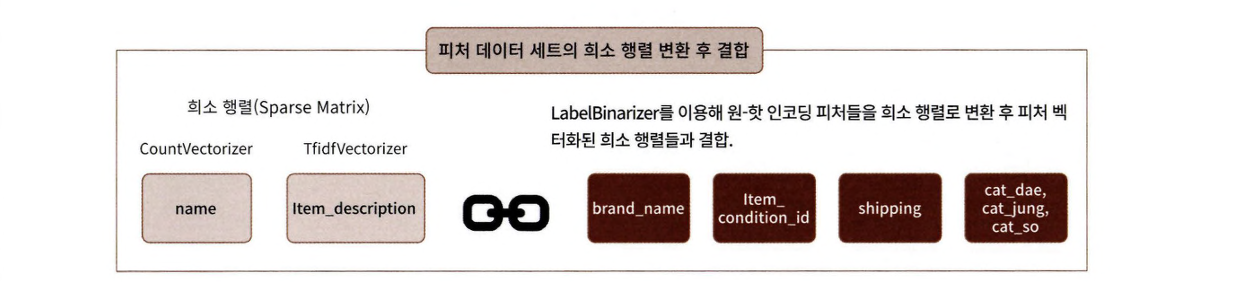

In [15]:
# 인코딩 대상 칼럼을 모두 LabelBinarizer로 원-핫 인코딩 변환

from sklearn.preprocessing import LabelBinarizer

# brand_name 피처를 희소 행렬 원-핫 인코딩 변환
lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])

# item_condition_id 피처를 희소 행렬 원-핫 인코딩 변환
lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])

# shipping 피처를 희소 행렬 원-핫 인코딩 변환
lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])


# cat_dae, cat_jung, cat_so 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_cat_dae.fit_transform(mercari_df['cat_dae'])
lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])
lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

In [16]:
# 제대로 변환됐는지 생성된 인코딩 데이터 세트의 타입과 shape 확인

print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand shape:{0}, X_item_cond_id shape:{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae shape:{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape:(1482535, 4810), X_item_cond_id shape:(1482535, 5)
X_shipping shape:(1482535, 1), X_cat_dae shape:(1482535, 11)
X_cat_jung shape:(1482535, 114), X_cat_so shape:(1482535, 871)


인코딩 변환된 데이터 세트가 CSR 형태로 변환된 csr_matrix 타입.
- brand_name 칼럼: 값의 유형이 4810개 -> 이를 원-핫 인코딩으로 변환한 X_brand_shape의 경우 4810개의 인
코딩 칼럼을 가지게 됨.
- X_cat_so 칼럼: 871개의 인코딩 칼럼을 가짐. 인코딩 칼럼이 매우 많이 생겼지만, 피처 벡터화로 텍스트 형태의 문자열이 가지는 벡터 형태의 매우 많은 칼럼과 함께 결합되므로 크게 문제 되지는 X

In [17]:
# 앞에서 피처 벡터화 변환한 데이터 세트 + 희소 인코딩 변환된 데이터 세트
# hstack()을 이용해 모두 결합

from scipy.sparse import hstack
import gc

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# hstack 함수를 이용해 인코딩과 벡터화를 수행한 데이터 세트를 모두 결합
X_features_sparse = hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)

# 데이터 세트가 메모리를 많이 차지하므로 사용 목적이 끝났으면 바로 메모리에서 삭제
del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (1482535, 161569)


0

hstack()으로 결합한 데이터 세트는 csr_matrix 타입이며, 총 161569개의 피처를 가지게 됨.

## 릿지 회귀 모델 구축 및 평가

만들어진 데이터 세트에 회귀를 적용해 price 값을 예측할 수 있도록 모델을 만들 차례!

- 테스트 수행에 필요한 로직 함수화.
    - 모델을 평가하는 평가(Evaluation) 로직을 함수화.
    - 적용할 평가 지표: 캐글에서 제시한 RMSLE(Root Mean Square Logarithmic Error) 방식
    
- RMSLE: RMSE와 유사하나 오류 값에 로그를 취해 RMSE를 구하는 방식. 가격(price)보다 높은 가격에서 오류가 발생할 경우 오류 값이 더 커지는 것을 억제하기 위해서 이 방식
을 도입함.

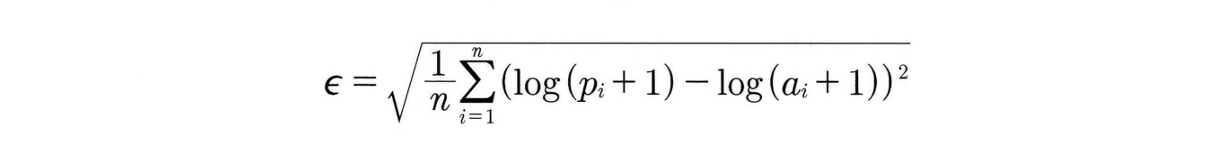

In [18]:
# evaluate_org_price(y_test, preds) 함수 생성

def rmsle(y, y_pred):
    # underflow, overflow를 막기 위해 log가 아닌 log1p로 rmsle 계산
    # 원본의 price 칼럼은 왜곡됨 -> 이를 정규 분포 형태로 유도하기 위해 로그 값을 취해 변환
    return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))

def evaluate_org_price(y_test, preds):
    # 원본 데이터는 log1p로 변환되었으므로 exmpm1로 원복 필요
    preds_exmpm = np.expm1(preds)
    y_test_exmpm = np.expm1(y_test)

    # 원복된 데이터를 기반으로 rmsle로 RMSLE 값 추출
    rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
    return rmsle_result

In [19]:
# model_train_predict() 함수 생성 - 학습용 데이터를 생성하고, 모델을 학습/예측

import gc
from scipy.sparse import hstack

# model 인자로 사이킷런의 회귀 estimator 객체를 가짐
# matrix_list 인자로 최종 데이터 세트로 결합할 희소 행렬 리스트를 가짐.
def model_train_predict(model, matrix_list):
    # scipy.sparse 모듈의 hstack을 이용해 희소 행렬 결합
    X = hstack(matrix_list)
    X = X.tocsr()

    X_train, X_test, y_train, y_test = train_test_split(X, mercari_df['price'],
                                                        test_size=0.2, random_state=156)

    # 모델 학습 및 예측
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    del X, X_train, X_test, y_train
    gc.collect()

    return preds, y_test

- 만든 개별 함수를 이용해 먼저 Ridge를 이용해 Mercari Price의 회귀 예측 수행
    - 수행 전에 Merari 상품 가격 예측에 item_description과 같은 텍스트 형태의 속성이 얼마나 영향을 미치는지 알아보기.

In [20]:
# item_description 속성의 피처 벡터화 데이터가 포함X vs 포함O 예측 성능을 비교

# 제외
linear_model = Ridge(solver = "lsqr", fit_intercept=False)

sparse_matrix_list = (X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description 제외 rmsle 값:', evaluate_org_price(y_test, linear_preds))


# 포함
sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description 포함 rmsle 값:', evaluate_org_price(y_test, linear_preds))

Item Description 제외 rmsle 값: 0.4983990938999374
Item Description 포함 rmsle 값: 0.4680432471796771


Item Description을 포함했을 때 rmsle 값이 많이 감소 -> Item description 영향이 중요함을 알 수 있음.

## LightGBM 회귀 모델 구축과 앙상블을 이용한 최종 예측 평가

LightGBM을 이용해 회귀를 수행한 뒤, \
위에서 구한 릿지 모델 예측값과 LightGBM 모델 예측값을 간단한 앙상블(Ensemble) 방식으로 섞어서 최종 회귀 예측값을 평가.

In [21]:
# LightGBM으로 회귀 수행

from lightgbm import LGBMRegressor

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=156)
lgbm_preds, y_test = model_train_predict(model=lgbm_model, matrix_list=sparse_matrix_list)
print('LightGBM 값:', evaluate_org_price(y_test, lgbm_preds))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1468.018244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1068323
[LightGBM] [Info] Number of data points in the train set: 1186028, number of used features: 65338
[LightGBM] [Info] Start training from score 2.979514


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LightGBM 값: 0.4563962127849484


앞 예제의 Ridge보다 예측 성능이 더 나아짐.

- 구한 LightGBM의 예측 결괏값과 위에서 구한 Ridge의 예측 결괏값을 서로 앙상블해 최종 예측 결괏값 도출.
- 0.45 * LightGBM 결괏값 + 0.55 * Ridge 결괏값 = 최종 예측 결괏값으로 함.(0.45와 0.55의 배합 비율은 임의로 산정함.)

In [22]:
# 앙상블
preds = lgbm_preds*0.45 + linear_preds*0.55
print('LightGBM과 Ridge를 ensemble한 최종 rmsle값:',evaluate_org_price(y_test, preds))

LightGBM과 Ridge를 ensemble한 최종 rmsle값: 0.4467272727321774


예측 성능이 더 개선됨

# 11 정리

이 장에서는 텍스트 분석을 위한 기반 프로세스를 상세히 알아보고, 이를 통해 **텍스트 분류, 감성 분석, 토픽 모델링, 텍스트 군집화 및 유사도 측정** 등을 직접 파이썬 코드를 이용해 구현함.
- 머신러닝 기반의 텍스트 분석 프로세스
    - 첫째: 텍스트 사전 정제 작업 등의 텍스트 정규화 작업 수행.
    - 둘째: 이들 단어들을 피처 벡터화로 변환.
    - 셋째: 이렇게 생성된 피처 벡터 데이터 세트에 머신러닝 모델을 학습하고 예측, 평가.

- 텍스트 정규화 작업
    - 텍스트 클렌징 및 대소문자 변경, 단어 토큰화, 의미 없는 단어 필터링, 어근 추출 등 피처 벡터화를 진행하기 이전에 수행하는 다양한 사전 작업을 의미함. 피처 벡터화는 BOW의 대표 방식인 Count 기반과 TF-IDF 기반 피처 벡터화를 설명함. 일반적으로 문서의 문장이 긴 경우 TF-IDF 기반의 피처 벡터가 더 정확한 결과를 도출하는 데 도움이 됨. 이렇게 만들어진 피처 벡터 데이터 세트는 희소 행렬이며, 머신러닝 모델은 이러한 희소 행렬 기반에서 최적화되어야 함.

---

- 텍스트 분류
    - 문서들을 피처 벡터화한 후 로지스틱 회귀를 적용해 문서를 지도학습 방식으로 예측 분류해 봄.
    
- 감성 분석
    - 지도학습 기반으로 긍정/부정 이진 분류를 적용한 방식과 SentiWordNet, VADER와 같은 감성 사전 Lexicon을 이용한 방식 두 가지를 살펴봄.

- 토픽 모델링
    - LDA(Latent Dirichlet Allocation)를 이용해 뉴스그룹 내의 많은 문서들이 공통적으로 가지는 토픽들을 추출해 봄.
    
- 텍스트 군집화
    - K-평균 군집화 기법 -> 비슷한 문서들끼리 군집화.

- 텍스트 유사도 측정
    - 코사인 유사도 -> 문서들끼리 얼마나 비슷한지 측정. 파이썬의 대표적인 한글 형태소 분석기인 KoNLPy 패키지를 이용해 네이버에서 제공하는 한글로 된 영화 리뷰에 긍정/부정 이진 분류를 적용해봄.
    
- Mercari Price Challenge 실습
    - 정형 피처들과 텍스트와 같은 비정형 피처를 결합해 효과적으로 회귀 예측 모델을 구현함.

> 결론: 기존의 데이터들과 이들 비정형 데이터가 결합된 형태로 제공되는 분석은 기존 분석이 가져다 주지 못한 새로운 인사이트들을 제공할 수 있음!